In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:

len(words)

32033

In [5]:

chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [217]:
block_size = 3 # context lenght : how many characters do we take to predict the next one
X, Y = [], []

for w in words:
	# print(w)
	context = [0] * block_size
	for ch in w + '.':
		ix = stoi[ch]
		X.append(context)
		Y.append(ix)
		# print(''.join(itos[i] for i in context), '--->', itos[ix])
		context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [14]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [15]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [16]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [218]:
C = torch.randn((27, 2))

In [19]:
C[5]

tensor([-0.3592, -0.4963])

In [25]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.3592, -0.4963])

In [28]:
C[X].shape

torch.Size([32, 3, 2])

In [29]:
X[13, 2]

tensor(1)

In [30]:
C[X][13,2]

tensor([0.1969, 0.4495])

In [31]:
C[1]

tensor([0.1969, 0.4495])

In [37]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [38]:

W1 = torch.randn((6, 100))
b1 = torch.randn(100)


In [39]:
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [45]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

In [49]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [52]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [53]:
a.shape

torch.Size([18])

In [56]:

a.view(3, 3, 2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [58]:
a.storage()

/var/folders/20/1_tbzzdn3_1gdk65rsv91_c40000gn/T/ipykernel_29472/214256462.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [59]:
emb.shape

torch.Size([32, 3, 2])

In [62]:

emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [63]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [69]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [70]:
h.shape

torch.Size([32, 100])

In [71]:
h

tensor([[-0.9999, -0.6579,  0.9868,  ..., -0.9996,  0.1424,  0.3857],
        [-1.0000, -0.9955,  0.8922,  ..., -0.9953,  0.2829, -0.4543],
        [-1.0000,  0.7295,  0.9921,  ..., -0.9961, -0.5267, -0.9383],
        ...,
        [ 0.0549, -0.9995,  0.8786,  ..., -0.5436, -0.3314,  0.9940],
        [-0.9998, -0.5228, -0.0027,  ..., -0.9956, -0.2926, -0.9984],
        [-0.2452,  0.9277,  0.9151,  ...,  0.5412, -0.8792,  0.8653]])

In [72]:
(emb.view(-1, 6) @ W1).shape

torch.Size([32, 100])

In [ ]:
b1.shape


torch.Size([100])

In [74]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [75]:
logits = h @ W2 + b2

In [76]:
logits.shape

torch.Size([32, 27])

In [78]:
counts = logits.exp()

In [79]:
prob = counts / counts.sum(1, keepdim=True)

In [80]:

prob.shape

torch.Size([32, 27])

In [82]:
prob[0].sum()

tensor(1.)

In [86]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(12.8524)

In [84]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [83]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [239]:
# Summary

In [ ]:
X.shape, Y.shape

(torch.Size([182778, 3]), torch.Size([182778]))

In [339]:

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [340]:
sum(p.nelement() for p in parameters)

3481

In [341]:
for p in parameters :
	p.requires_grad = True

In [342]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre


In [ ]:
lri = []
lossi = []

for i in range(10000):
	# mini batch
	ix = torch.randint(0, X.shape[0], (32, ))

	# forward pass
	emb = C[X[ix]]
	h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 32, 100
	logits = h @ W2 + b2
	loss = F.cross_entropy(logits, Y[ix])
	# print(loss.item())

	#backward pass
	for p in parameters :
		p.grad = None
	loss.backward()

	#update
	lr = 0.001
	for p in parameters:
		p.data += -lr * p.grad

	# # track stats
	# lri.append(lre[i])
	# lossi.append(loss.item())
# print(loss.item())


In [380]:
emb = C[X[ix]]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 32, 100
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y[ix])
loss

tensor(2.1525, grad_fn=<NllLossBackward0>)

In [381]:
# train, dev, test
# 80, 10, 10



In [552]:
def build_dataset(words):
	block_size = 3 # context lenght : how many characters do we take to predict the next one
	X, Y = [], []
	for w in words:
		# print(w)
		context = [0] * block_size
		for ch in w + '.':
			ix = stoi[ch]
			X.append(context)
			Y.append(ix)
			# print(''.join(itos[i] for i in context), '--->', itos[ix])
			context = context[1:] + [ix] # crop and append

	X = torch.tensor(X)
	Y = torch.tensor(Y)
	print(X.shape, Y.shape)
	return X, Y

import random
random.seed(42)
ws = words[:] # copie, on ne mélange pas words en place
random.shuffle(ws)
n1, n2 = int(0.8 * len(ws)), int(0.9 * len(ws))
Xtr, Ytr = build_dataset(ws[:n1])
Xdev, Ydev = build_dataset(ws[n1:n2])
Xte, Yte = build_dataset(ws[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [553]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [554]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [555]:
sum(p.nelement() for p in parameters)

11897

In [556]:
for p in parameters :
	p.requires_grad = True

In [557]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [558]:
lri = []
lossi = []
stepi = []

In [559]:
for i in range(200000):
	# mini batch
	ix = torch.randint(0, Xtr.shape[0], (32, ))

	# forward pass
	emb = C[Xtr[ix]]
	h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # 32, 100
	logits = h @ W2 + b2
	loss = F.cross_entropy(logits, Ytr[ix])
	# print(loss.item())

	#backward pass
	for p in parameters :
		p.grad = None
	loss.backward()

	#update
	lr = 0.1 if i < 100000 else 0.01
	for p in parameters:
		p.data += -lr * p.grad

	# # track stats
	# lri.append(lre[i])
	lossi.append(loss.log10().item())
	stepi.append(i)
# print(loss.item())


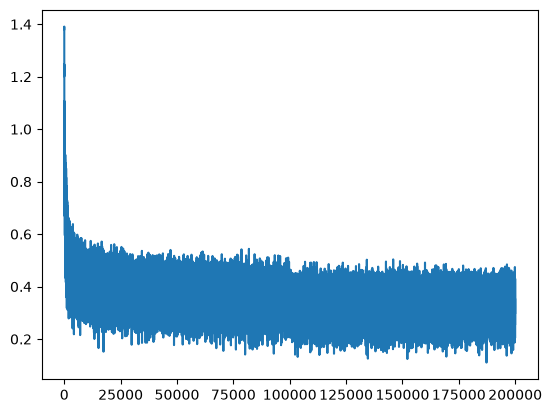

In [560]:
plt.plot(stepi, lossi)

In [561]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # 32, 100
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1188, grad_fn=<NllLossBackward0>)

In [562]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # 32, 100
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1688, grad_fn=<NllLossBackward0>)

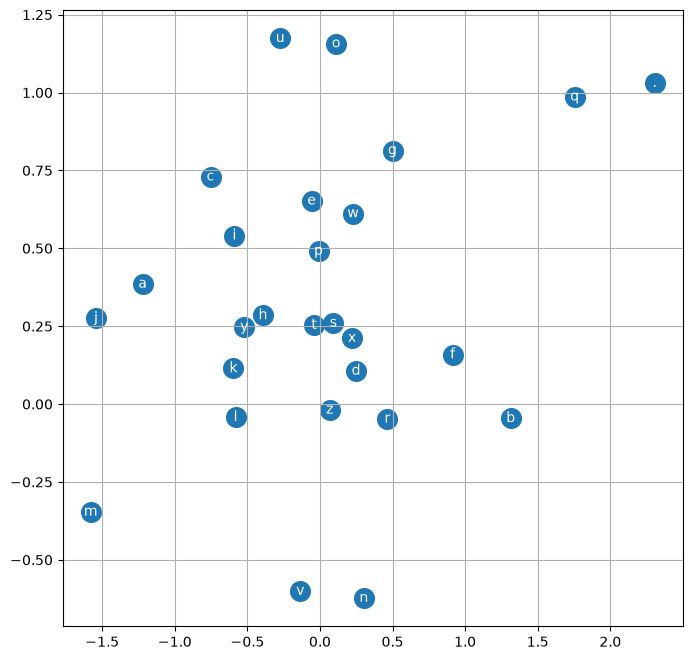

In [551]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
	plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')